In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix


In [7]:
df = pd.read_csv("Titanic-Dataset.csv")

In [8]:
df.corr(numeric_only = True)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [9]:
df.dropna(inplace=True)


## we are not performing any eda because we are understanding concepts and practical

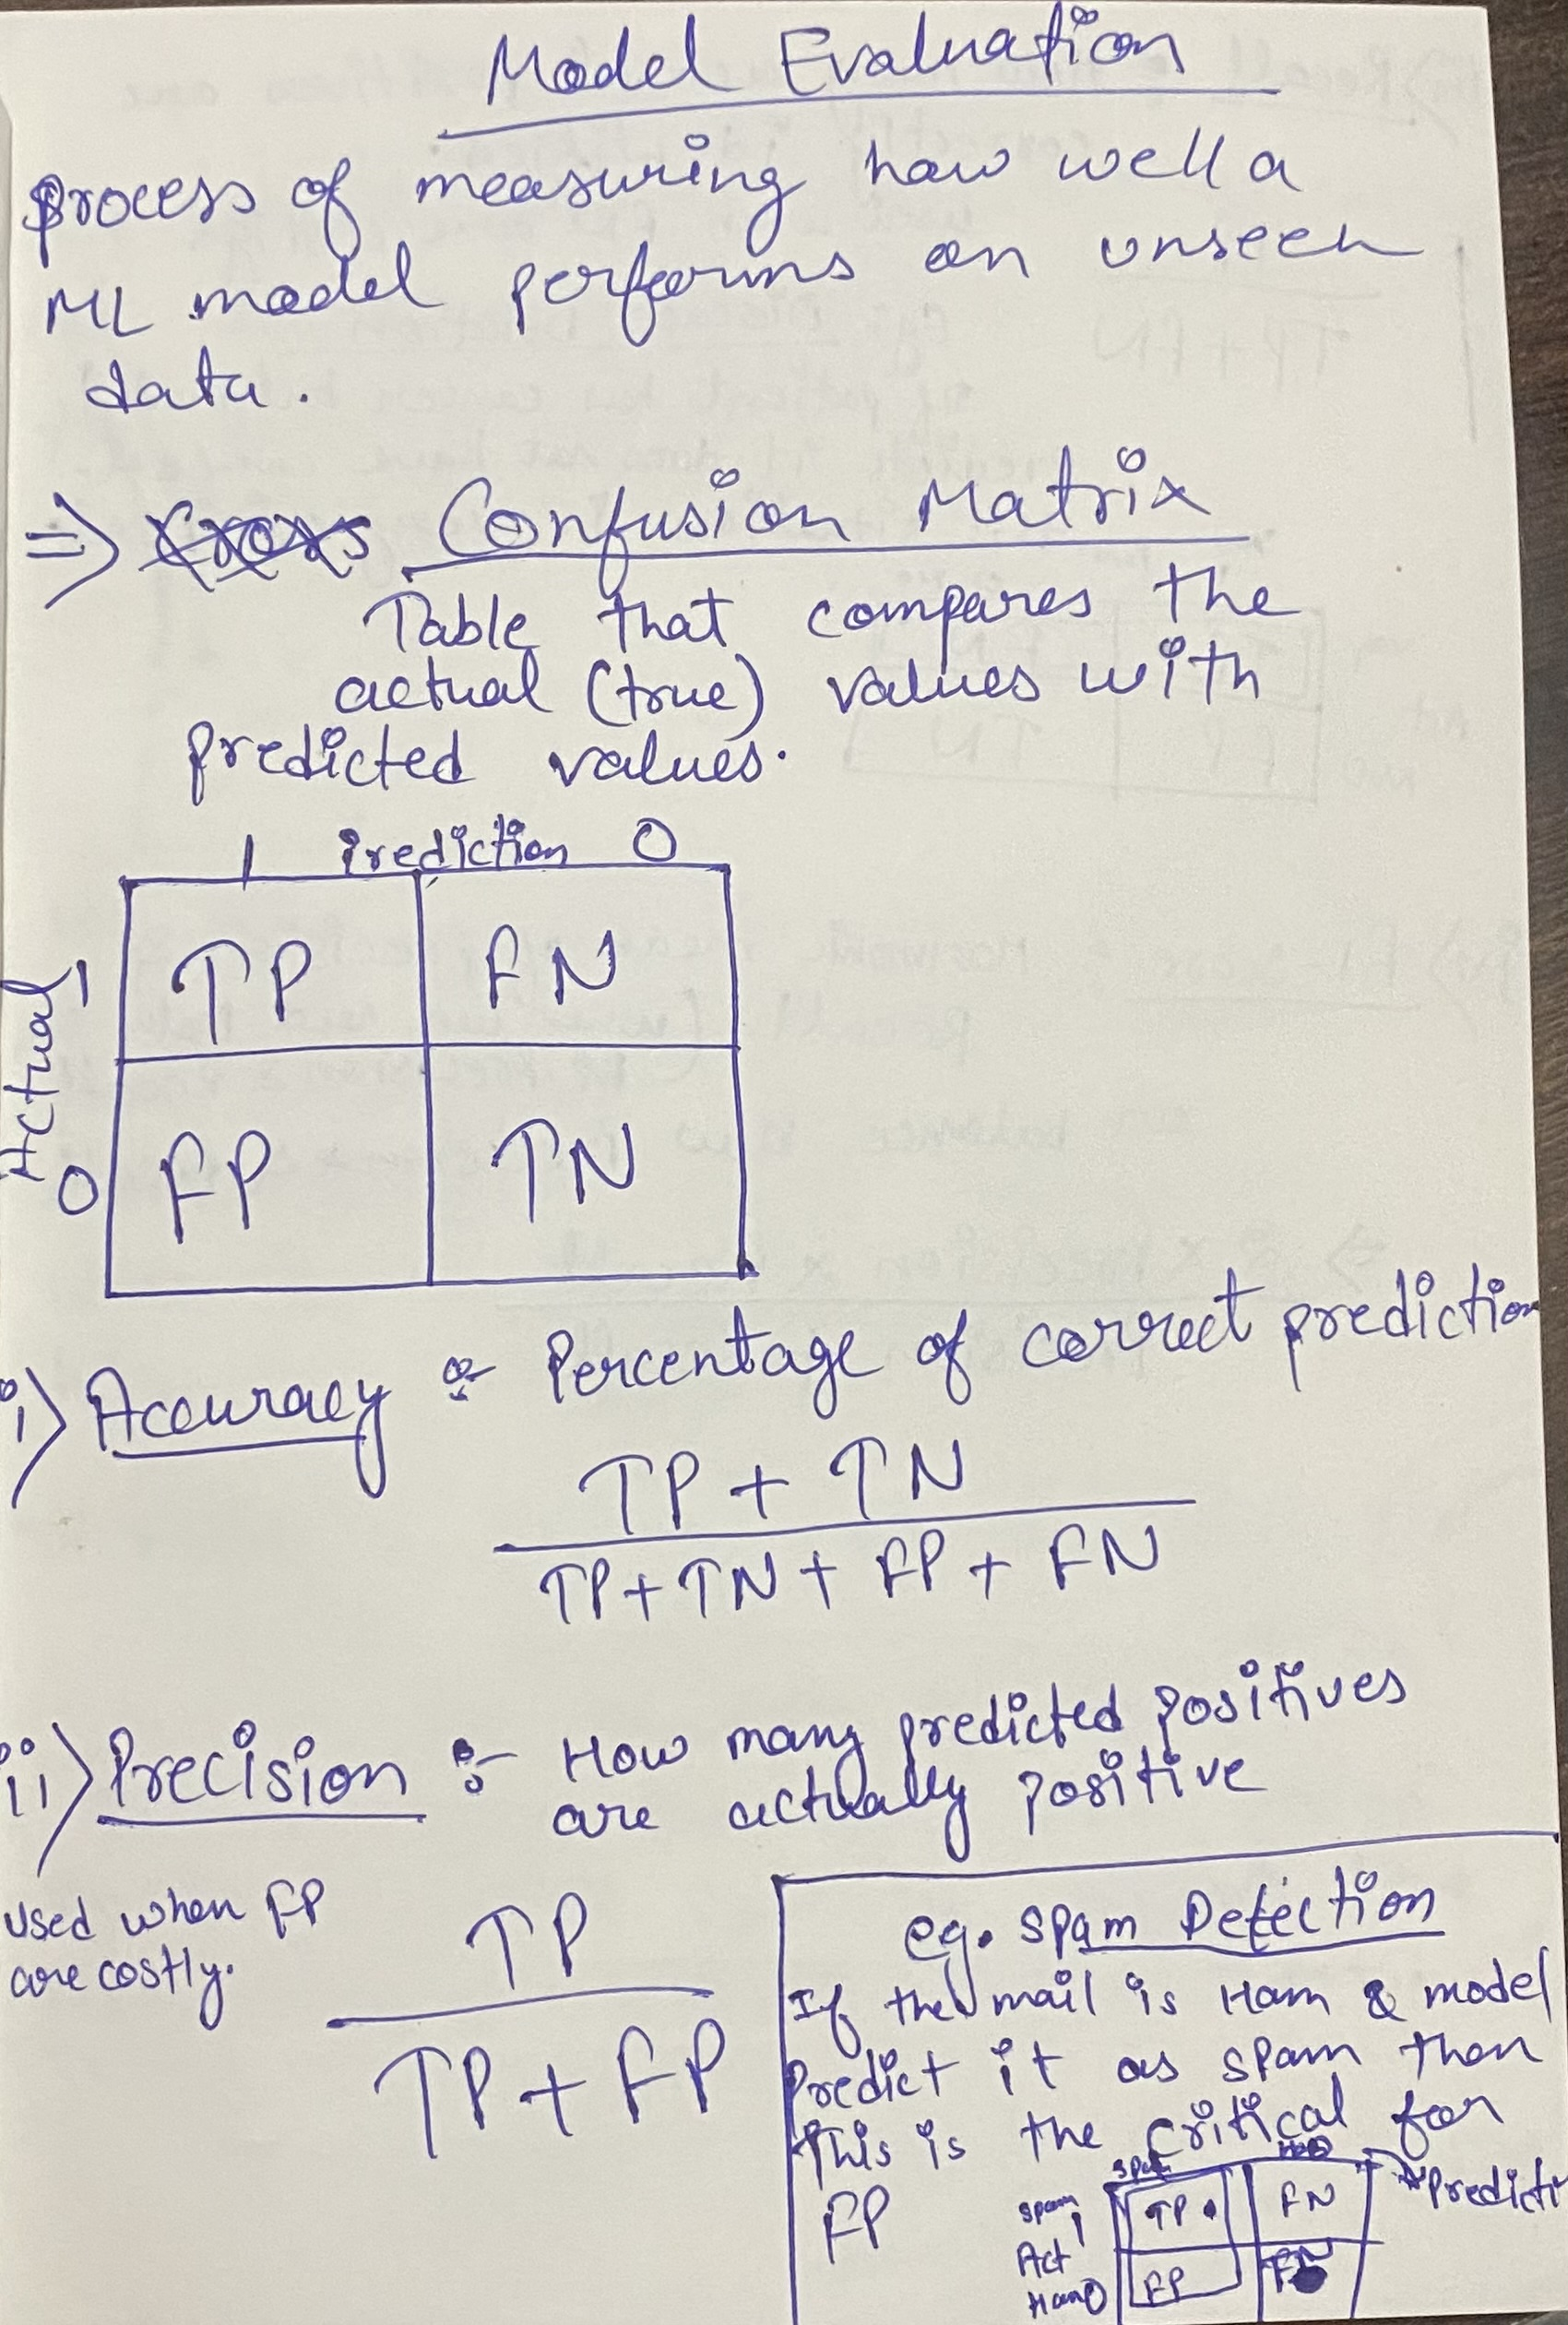
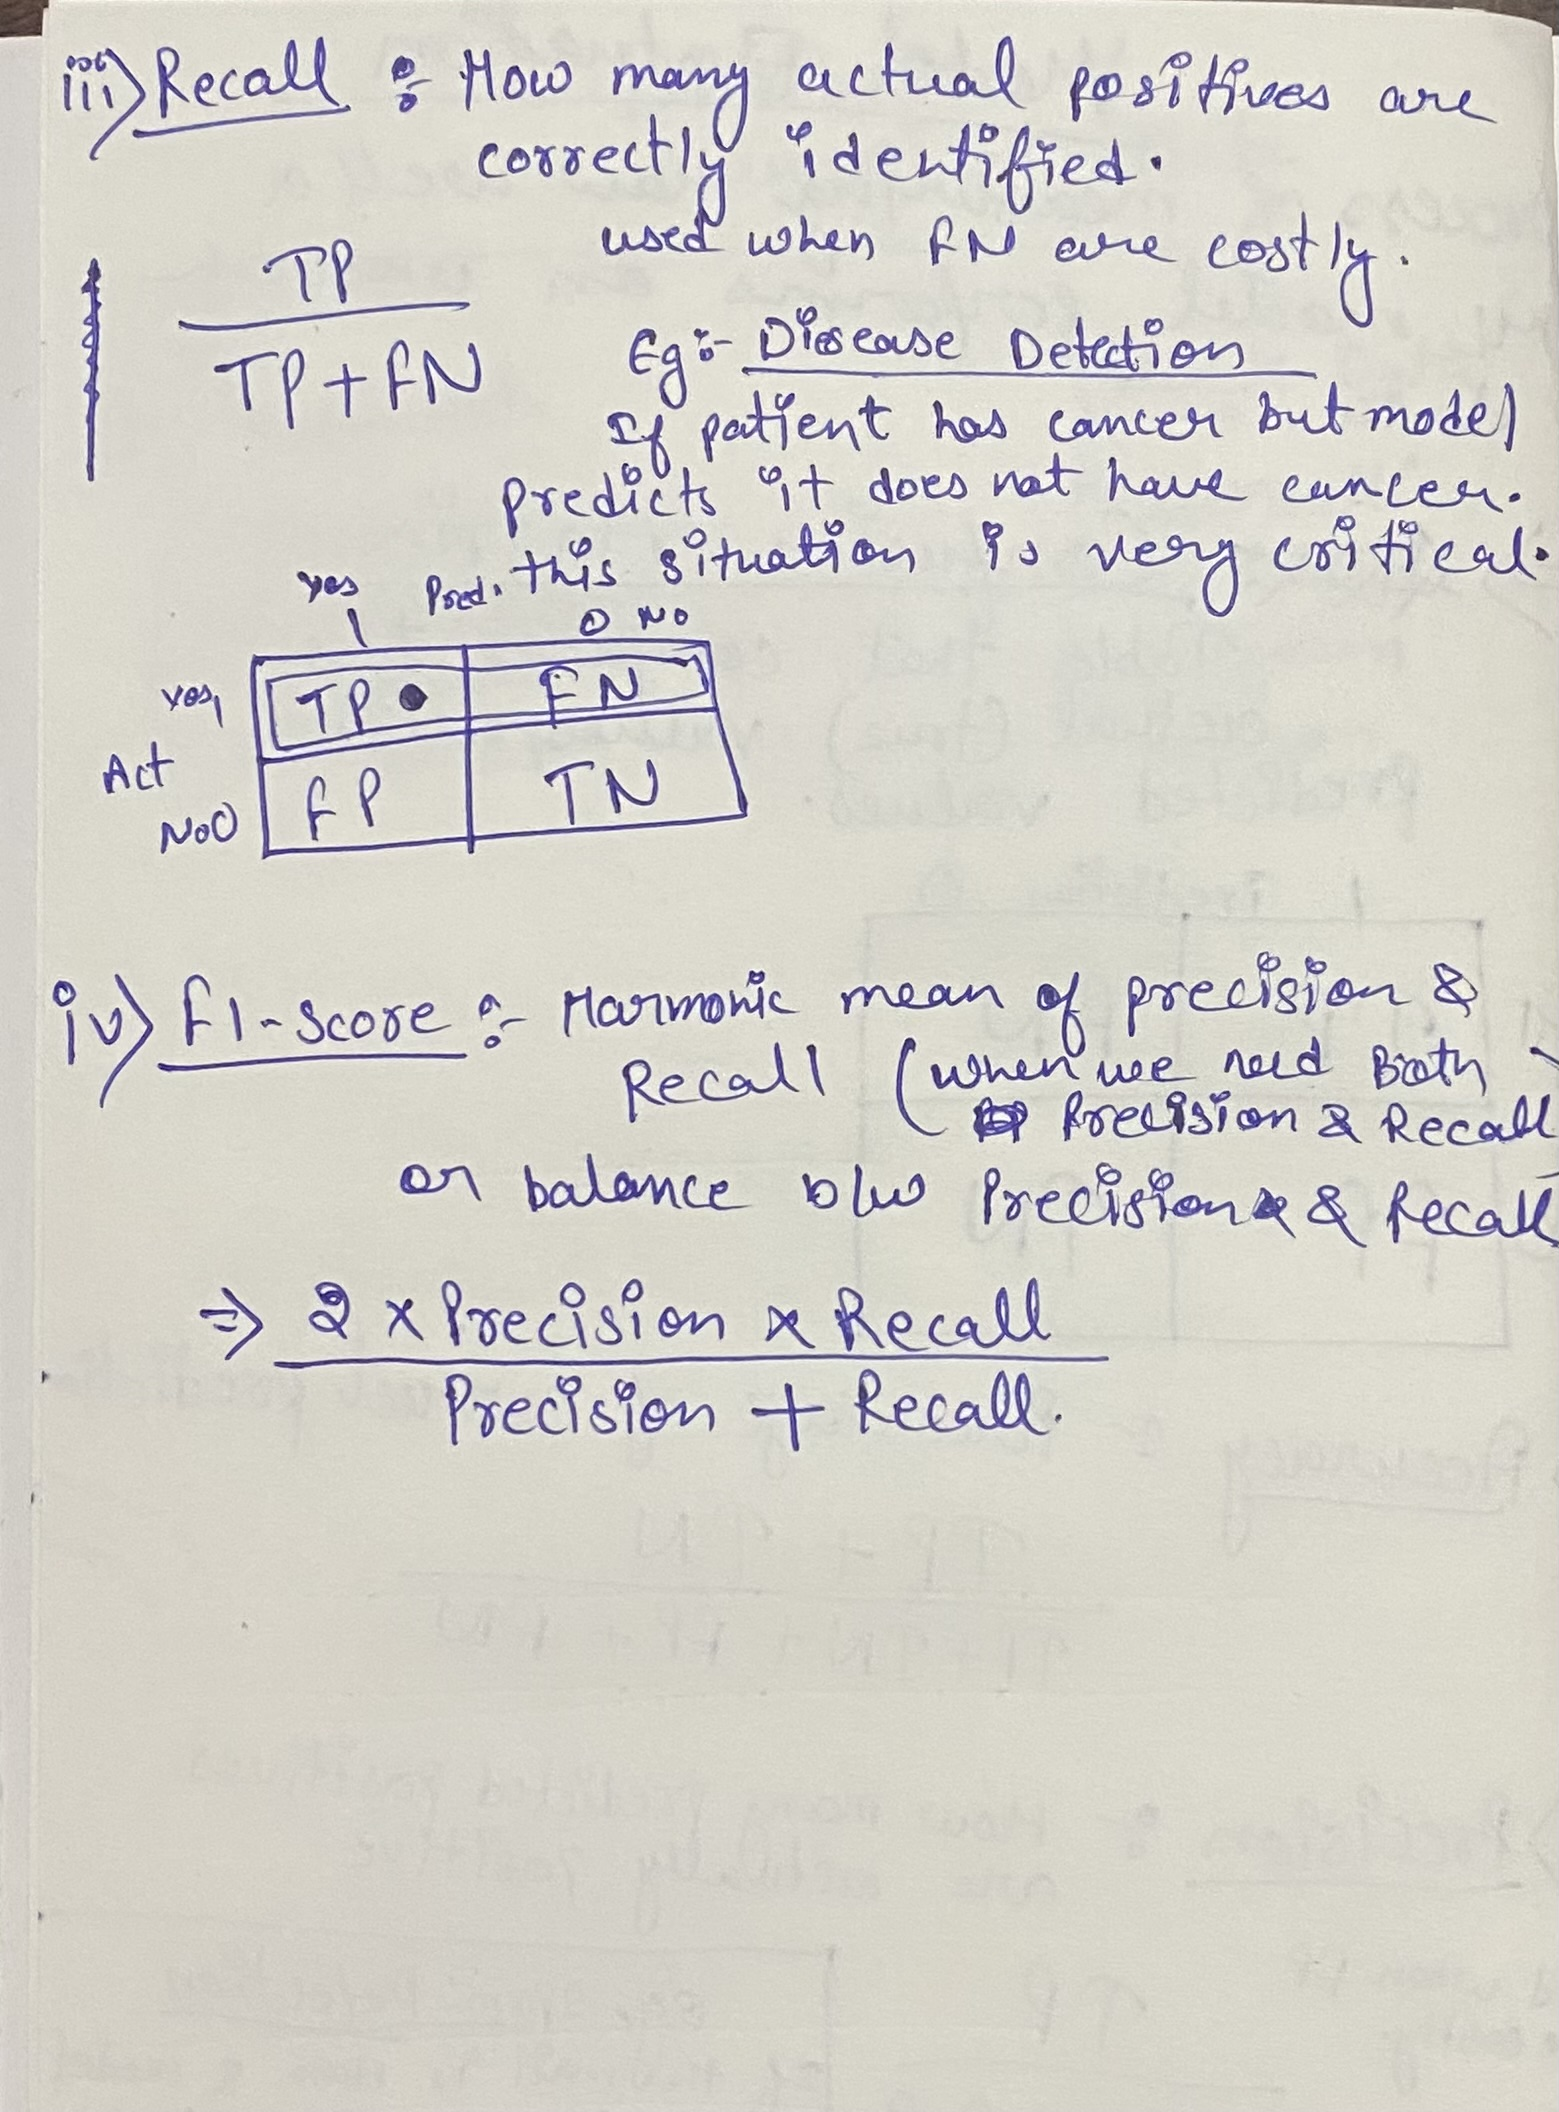

In [10]:
x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])


In [11]:
label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked'])
x['Sex'] = label.fit_transform(x['Sex'])

In [12]:
y = df['Survived']


In [13]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )


In [14]:
model = LogisticRegression()

In [15]:
model.fit(x_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
y_pred=model.predict(x_test)

In [20]:
confusion_matrix(y_test, y_pred)

array([[11,  1],
       [ 8, 17]])

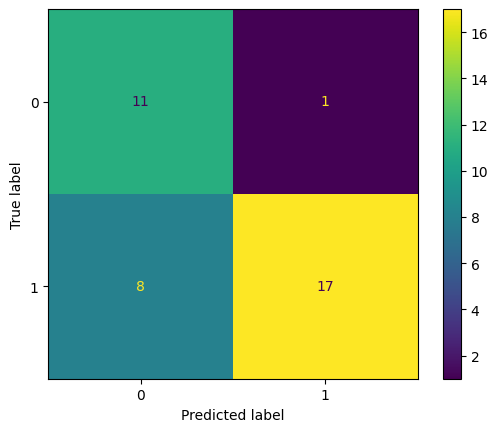

In [21]:
# or we can display the confusion_matrix in graphical manner
from sklearn.metrics import ConfusionMatrixDisplay
con_mat = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(con_mat).plot()

In [22]:
precision_score(y_test, y_pred)

0.9444444444444444

In [23]:
recall_score(y_test, y_pred)

0.68

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.92      0.71        12
           1       0.94      0.68      0.79        25

    accuracy                           0.76        37
   macro avg       0.76      0.80      0.75        37
weighted avg       0.83      0.76      0.76        37



In [ ]:
# on the basis of our requirements we can modify or tune our model so we can reduce our precision,